### Practical Work

1. Train a RF on TF-8Bind data. 
2. Predict new sequences with SMW from seed sequence
3. Score unique unssen predicted sequences
4. best sequence == new seed
5. plot how good prediciton is against real world labels


In [9]:
# Imports
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from split.create_split import create_split
from models.oracle import build_oracle_one_hot_df, oracle_score_range
from models.single_mutant_walker import SMW
from models.lstm import LSTMSequencePredictor
from models.random_forest import RandomForestPredictor
from main_scorer import mutate_score_sequences, lookup_oracle, plot_results
from models.lstm import train, save_model, load_model

SEED = 42

/Users/meier/Documents/PracticalWork/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Prepare Dataset: 
Der Trainingssatz, der den Offline-MBO-Algorithmen zur Verfügung gestellt wird, ist auf die unteren 50 % beschränkt, was zu einem sichtbaren Trainingssatz von 32898 Proben führt.

In [3]:
# Load dataset: TFBIND 8 - SIX6 REF R1
df = pd.read_csv('tf_bind_8-SIX6_REF_R1/dataset.csv')
df['split'] = ['None'] * len(df)

df = create_split(df, k_seeds=50, n_training_seeds=20, random_state=42)
df.head()

train_df = df[df['split'] == 'train']

x = train_df.iloc[:, :-5].values
print('Shape of x:', x.shape)
print('First row of x:', x[0])
y = train_df['binding_scores'].values

X_train, X_val, y_train, y_val = train_test_split(x, y, test_size=0.1, random_state=SEED)
# One hot encoding
X_train_onehot = np.array([tf.one_hot(seq, depth=4).numpy() for seq in X_train]) # Remove .flatten() for LSTM
X_val_onehot = np.array([tf.one_hot(seq, depth=4).numpy() for seq in X_val]) # Remove .flatten() for LSTM



Shape of x: (8670, 8)
First row of x: [0 0 0 0 0 0 2 1]


In [3]:
lstm = LSTMSequencePredictor(input_size=4, lstm_units=100, dense_units=4, dropout_rate=0.2)
history = train(
    model=lstm,
    X_train = X_train_onehot, 
    y_train = y_train,
     X_val= X_val_onehot,
      y_val = y_val, 
      epochs=2, 
      batch_size=32)

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x72ea4d8b1090>>
Traceback (most recent call last):
  File "/home/meier/Desktop/PracticalWork/.venv/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 797, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


Epoch 1/2 - loss: 0.0078 - val_loss: 0.0055
Epoch 2/2 - loss: 0.0056 - val_loss: 0.0051


Next cell creates a dataframe with binding scores and one hot encoded sequences for the lookup task. 

In [5]:
save_model(lstm,'lstm_model_TFBind.pt')

In [4]:
# create dataframe for lookup task
test_df = df[df['split'] == 'test_a']
# just use <0.5 binding scores for the oracle
#test_df = test_df[test_df['binding_scores'] < 0.5]

df_oracle = build_oracle_one_hot_df(test_df)

# print highest value and lowest value in oracle
min_score, max_score = oracle_score_range(df_oracle)
print(f'Oracle binding score range: {min_score} - {max_score}')

Oracle binding score range: 0.05901332 - 0.993908


#### Random Forest

In [5]:
rf = RandomForestPredictor(seed=SEED)
rf.train(X_train_onehot.reshape(X_train_onehot.shape[0], -1), y_train)
metrics = rf.evaluate(X_val_onehot.reshape(X_val_onehot.shape[0], -1), y_val)
#rf.save_model('models/random_forest_TFBind8.pkl')

Training Random Forest model...
Training completed.
R2 Score: 0.16963370553361423
MSE: 0.0048524593696974445
Spearman Correlation: 0.38823061001248516


#### LSTM Model 

In [4]:
model = load_model('lstm_model_TFBind.pt')

### Mutation and Scoring loop
1. One Mutation from Single Mutant Walker
2. Predict with RF
3. Normalize Predicted score to range 0-1
4. If score is higher -> save sequence else continue with old seed
5. Lookup real scores and plot trajectories

In [ ]:

# Initialize the Single Mutant Walker
smw = SMW(nucleotides= [0, 1, 2, 3])
n_steps = 100
mutation_steps = 10

scorer = rf

# Select a random seed sequence from the test set
seed_sequence = X_train[0]
old_score = y_train[0]
print(f"Seed sequence: {seed_sequence}, Score: {old_score:.4f}")
scored_sequences = [i.flatten() for i in X_train_onehot]

# Perform mutation walk
values = mutate_score_sequences(smw, 
                                scorer=scorer,
                                oracle=df_oracle, 
                                seed_sequence=seed_sequence, 
                                score_seed_sequence=old_score, 
                                scored_sequences=scored_sequences, 
                                steps=n_steps, 
                                num_mutations=mutation_steps)

df_values = pd.DataFrame(values)
df_values = lookup_oracle(df_values, df_oracle)

/Users/meier/Documents/PracticalWork/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Seed sequence: [2 2 1 0 0 1 1 1], Score: 0.2401
Step 1, Mutation 3: New score 0.3109 (improved from 0.3109)
Step 2, Mutation 3: New score 0.3208 (improved from 0.3208)
Step 3, Mutation 1: New score 0.3214 (improved from 0.3214)
Step 4, Mutation 2: New score 0.3514 (improved from 0.3514)
Step 4, Mutation 3: New score 0.3519 (improved from 0.3519)
Step 5, Mutation 2: New score 0.3598 (improved from 0.3598)
Step 5, Mutation 4: New score 0.3642 (improved from 0.3642)
Step 6, Mutation 1: New score 0.3658 (improved from 0.3658)
Step 6, Mutation 4: New score 0.3659 (improved from 0.3659)
Step 6, Mutation 6: New score 0.3753 (improved from 0.3753)
Step 8, Mutation 3: New score 0.3766 (improved from 0.3766)
Step 8, Mutation 4: New score 0.3785 (improved from 0.3785)


Spearman Correlation: 0.3916


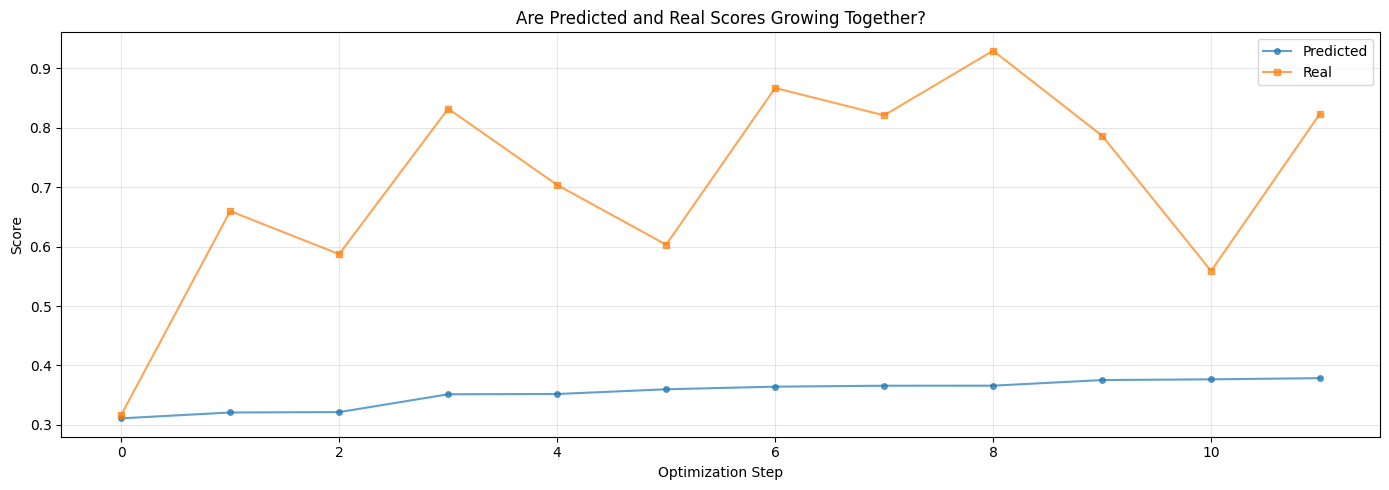

In [8]:
plot_results(df_values)

In [9]:
df_values['pred_direction'] = df_values['predicted_score'].diff() > 0
df_values['real_direction'] = df_values['real_score'].diff() > 0
direction_agreement = (df_values['pred_direction'] == df_values['real_direction']).mean()
print(f'Direction agreement: {direction_agreement:.1%}')

Direction agreement: 50.0%


In [ ]:
# save the results to a csv file for further analysis
df_values.to_csv('mutation_walk_results.csv', index=False)

Notes:
1. Testset A: spearman Correlation: 0.683, direction_agreement 66.7%
    Testset A > 0.5: spearman: 0.476, direction: 58.3%
    Testset A < 0.5: spearman: 0.413, direction: 58.3%
2. Testset B: spearman Correlation: 0.524, direction_agreement 58.3%
    Testset B > 0.5: spearman: 0.817 , direction: 55.6%
    Testset B < 0.5: spearman: -0.095, direction: 75.0%
3. Testset C: spearman Correlation: 0.764, direction_agreement 72.7


LSTM:
Testset A: spearman: 0.321, direction 57.1%
Testset B: spearman: 0.915, direction 70%
Testset C: spearman: 0.433, direction 57.1% 

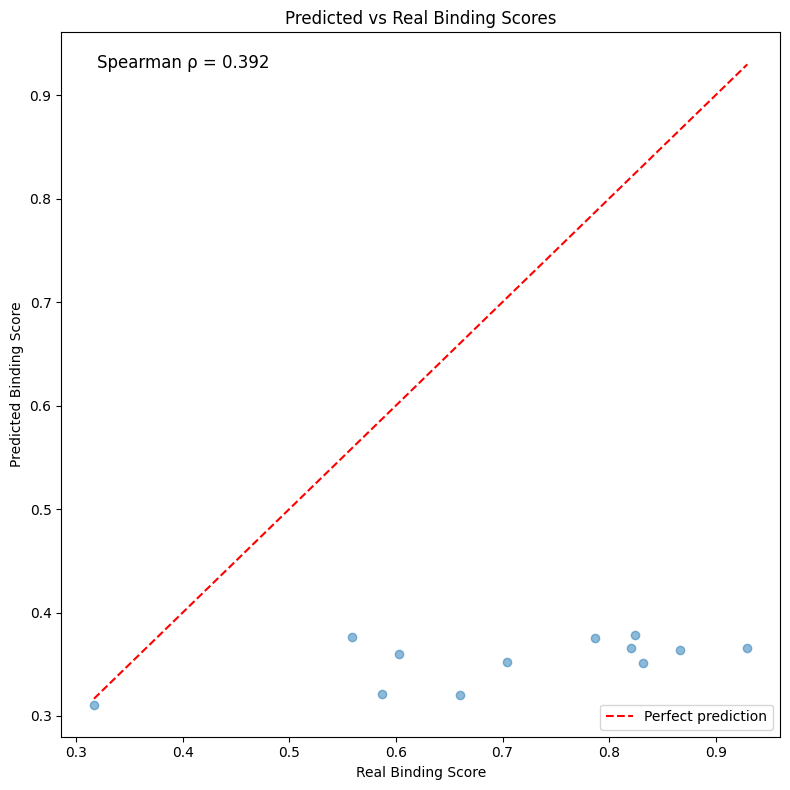

In [10]:
# Scatter plot shows correlation regardless of absolute values
plt.figure(figsize=(8, 8))
plt.scatter(df_values['real_score'], df_values['predicted_score'], alpha=0.5)
plt.plot([df_values['real_score'].min(), df_values['real_score'].max()], 
         [df_values['real_score'].min(), df_values['real_score'].max()], 
         'r--', label='Perfect prediction')
plt.xlabel('Real Binding Score')
plt.ylabel('Predicted Binding Score')
plt.title('Predicted vs Real Binding Scores')
plt.legend()

# Add Spearman correlation to plot
from scipy.stats import spearmanr
corr, _ = spearmanr(df_values['real_score'], df_values['predicted_score'])
plt.text(0.05, 0.95, f'Spearman ρ = {corr:.3f}', transform=plt.gca().transAxes, fontsize=12)
plt.tight_layout()
plt.show()

### Plot the trajcectories into a Scatterplot

/Users/meier/Documents/PracticalWork/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/_2/6p52z75d21dc91tc6ss7n6w80000gn/T/ipykernel_4685/685193560.py:62: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(embedding_trajectory[0, 0], embedding_trajectory[0, 1],
/var/folders/_2/6p52z75d21dc91tc6ss7n6w80000gn/T/ipykernel_4685/685193560.py:65: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(embedding_trajectory[-1, 0], embedding_trajectory[-1, 1],


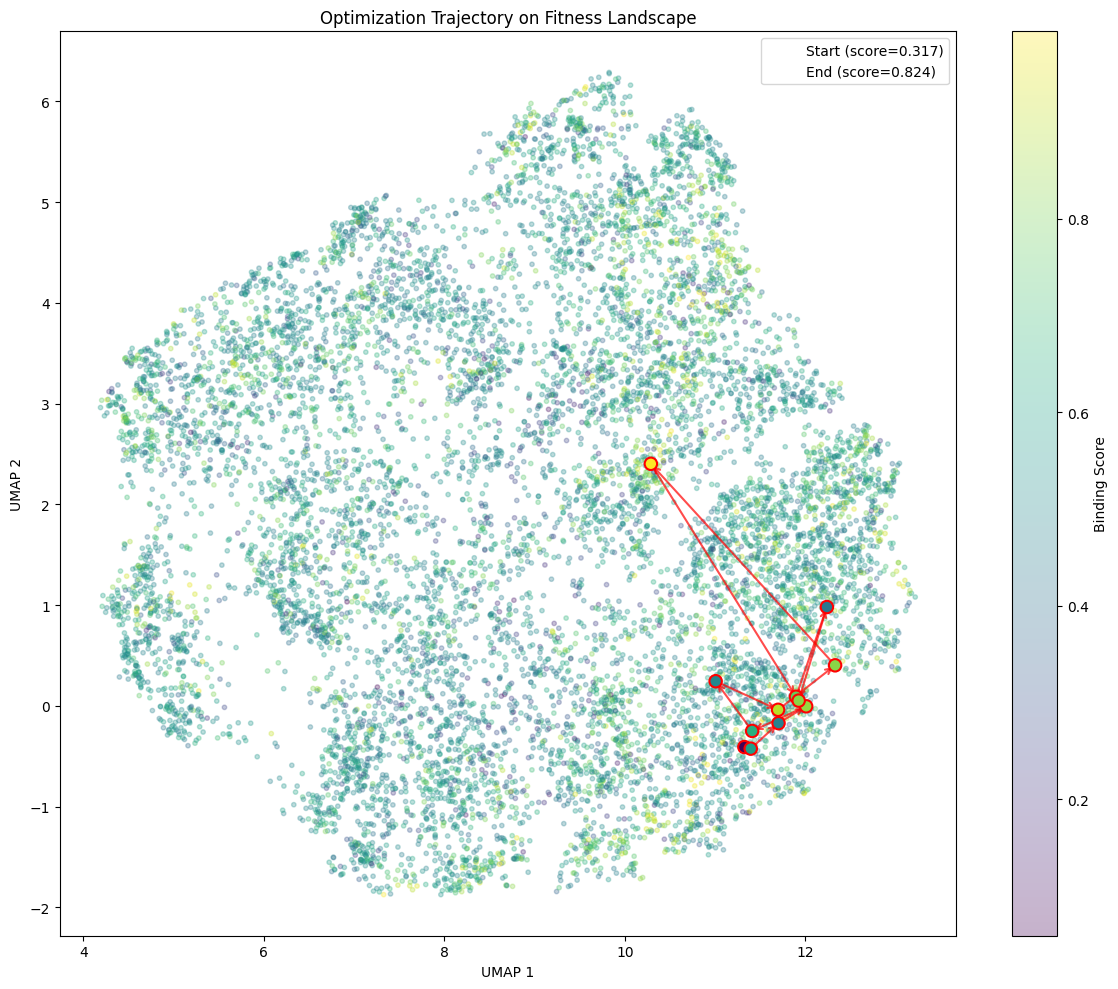

In [11]:
from matplotlib.patches import FancyArrowPatch
import umap
from sklearn.preprocessing import StandardScaler

# Prepare all sequences for embedding (oracle + trajectory)
X_oracle_onehot = np.vstack(df_oracle['one_hot_seq'].values)
X_trajectory = np.vstack(df_values['mutation'].values)

# Combine for consistent embedding
X_combined = np.vstack([X_oracle_onehot, X_trajectory])

# Fit UMAP on combined data
reducer = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(X_combined)

# Split back
n_oracle = len(X_oracle_onehot)
embedding_oracle = embedding[:n_oracle]
embedding_trajectory = embedding[n_oracle:]

# Get scores for coloring
oracle_scores = df_oracle['binding_scores'].values
trajectory_real_scores = df_values['real_score'].values


fig, ax = plt.subplots(figsize=(12, 10))


# Background landscape
scatter = ax.scatter(
    embedding_oracle[:, 0], 
    embedding_oracle[:, 1], 
    c=oracle_scores, 
    cmap='viridis', 
    alpha=0.3, 
    s=10
)
plt.colorbar(scatter, label='Binding Score')

# Draw arrows between consecutive trajectory points
for i in range(len(embedding_trajectory) - 1):
    ax.annotate(
        '', 
        xy=(embedding_trajectory[i+1, 0], embedding_trajectory[i+1, 1]),
        xytext=(embedding_trajectory[i, 0], embedding_trajectory[i, 1]),
        arrowprops=dict(arrowstyle='->', color='red', lw=1.5, alpha=0.7)
    )

# Trajectory points colored by score
ax.scatter(
    embedding_trajectory[:, 0], 
    embedding_trajectory[:, 1], 
    c=trajectory_real_scores,
    cmap='viridis',
    edgecolors='red',
    linewidths=1.5,
    s=80,
    zorder=5
)

# Start and end markers
ax.scatter(embedding_trajectory[0, 0], embedding_trajectory[0, 1], 
           c='lime', s=250, marker='', edgecolors='black', linewidths=2,
           label=f'Start (score={trajectory_real_scores[0]:.3f})', zorder=10)
ax.scatter(embedding_trajectory[-1, 0], embedding_trajectory[-1, 1], 
           c='red', s=250, marker='', edgecolors='black', linewidths=2,
           label=f'End (score={trajectory_real_scores[-1]:.3f})', zorder=10)

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('Optimization Trajectory on Fitness Landscape')
ax.legend(loc='upper right')
plt.tight_layout()
#plt.savefig('LSTM_fitness_landscape_trajectory_testset_b.png', dpi=150)
plt.show()

### Aggregation of Data over more runs
To see the behavior of the SMW and RF more then one single run is neccessare due to the randomness of the mutation. The question is if the SMW is ending up at the same/close sequences and/or clusters or if it is behaving different at every run. 
Therefore different metrics are calculated: 
- Mean / Std of best predicted score to see how well the optimizer did
- Mean / Std of best real score to see the actual optimization
- Mean / Std of the number of improvements found

Further analyze sequence clustering to see if simmilar sequences are found. (Hamming distance)

Quality ranking: Mean/Std of Spearman correlation between redicted and real scores and direction agreement.


In [6]:
from collections import defaultdict
from scipy.spatial.distance import pdist
from scipy.stats import spearmanr

def run_multiple_walks(n_walks=10, **kwargs):
    """
    Run multiple mutation walks and collect all data into a single DataFrame.
    
    Returns:
        df_all: DataFrame with columns [run_id, step, predicted_score, real_score, mutation]
    """
    all_data = []

    for run_id in range(n_walks):
        print(f'============ Starting walk {run_id+1}/{n_walks} ==============')

        #For a test reset the scored sequences to the original training set for each walk
        kwargs['scored_sequences'] = [i.flatten() for i in X_train_onehot]

        # get lower half of training data for seeds
        seed_idx = 0 #np.random.randint(len(X_train))
        seed_sequence = X_train[seed_idx]
        old_score = y_train[seed_idx]
        print(f"Seed sequence: {seed_sequence}, Score: {old_score:.4f}, Seen sequences: {len(kwargs.get('scored_sequences', []))}")
        
        values = mutate_score_sequences(  
            seed_sequence=seed_sequence,
            score_seed_sequence=old_score,
            **kwargs
        )
        
        if values is not None and len(values['mutation']) > 0:
            df_run = pd.DataFrame(values)
            df_run = lookup_oracle(df_run, df_oracle)
            
            # Add run metadata
            df_run['run_id'] = run_id + 1
            df_run['step'] = range(len(df_run))
            
            all_data.append(df_run)
            print(f"Found {len(df_run)} improvements")
        else:
            print("No improvements found in this run")
        print('\n')
    
    if all_data:
        df_all = pd.concat(all_data, ignore_index=True)
        # Reorder columns for clarity
        cols = ['run_id', 'step', 'predicted_score', 'real_score', 'mutation']
        df_all = df_all[[c for c in cols if c in df_all.columns]]
        return df_all
    else:
        return pd.DataFrame(columns=['run_id', 'step', 'predicted_score', 'real_score', 'mutation'])


def compute_aggregate_stats(df_all):
    """
    Compute aggregate statistics from the collected walk data.
    
    Args:
        df_all: DataFrame from run_multiple_walks
        
    Returns:
        summary: dict with aggregate metrics
        per_run_stats: DataFrame with per-run statistics
    """
    if df_all.empty:
        print("Warning: No data to compute statistics")
        return {}, pd.DataFrame()
    
    # Per-run statistics
    per_run_stats = df_all.groupby('run_id').agg(
        best_predicted=('predicted_score', 'max'),
        best_real=('real_score', 'max'),
        final_predicted=('predicted_score', 'last'),
        final_real=('real_score', 'last'),
        trajectory_length=('step', 'count')
    ).reset_index()
    
    # Compute Spearman correlation per run
    spearman_scores = []
    for run_id in df_all['run_id'].unique():
        run_data = df_all[df_all['run_id'] == run_id]
        if len(run_data) > 1:
            corr, _ = spearmanr(run_data['predicted_score'], run_data['real_score'])
            spearman_scores.append({'run_id': run_id, 'spearman': corr})
        else:
            spearman_scores.append({'run_id': run_id, 'spearman': np.nan})
    
    per_run_stats = per_run_stats.merge(pd.DataFrame(spearman_scores), on='run_id')
    
    # Aggregate summary (mean ± std)
    summary = {}
    for col in ['best_predicted', 'best_real', 'final_predicted', 'final_real', 'trajectory_length', 'spearman']:
        values = per_run_stats[col].dropna()
        summary[f'{col}_mean'] = values.mean()
        summary[f'{col}_std'] = values.std()
    
    # Sequence diversity: Hamming distance between final sequences from each run
    final_sequences = df_all.groupby('run_id').last()['mutation'].values
    if len(final_sequences) > 1:
        seq_matrix = np.vstack(final_sequences)
        pairwise_dist = pdist(seq_matrix, metric='hamming')
        summary['endpoint_diversity_mean'] = np.mean(pairwise_dist)
        summary['endpoint_diversity_std'] = np.std(pairwise_dist)
    
    return summary, per_run_stats

In [10]:
# Run multiple walks and collect all data
scored_sequences = [i.flatten() for i in X_train_onehot]

smw = SMW(nucleotides= [0, 1, 2, 3])
scorer = rf

df_all_walks = run_multiple_walks(
    n_walks=10,
    mutation_model=smw,
    scorer=scorer,
    oracle=df_oracle,
    scored_sequences=scored_sequences,
    steps=100,
    num_mutations=10
)

# View the collected data
print(f"Total data points: {len(df_all_walks)}")
print(f"Runs with data: {df_all_walks['run_id'].nunique()}")
df_all_walks.head(10)

============ Starting walk 1/10 ==============
Seed sequence: [2 2 1 0 0 1 1 1], Score: 0.2401, Seen sequences: 7803
Step 1, Mutation 3: New score 0.3109 (improved from 0.3109)
Step 2, Mutation 3: New score 0.3208 (improved from 0.3208)
Step 3, Mutation 1: New score 0.3214 (improved from 0.3214)
Step 4, Mutation 2: New score 0.3514 (improved from 0.3514)
Step 4, Mutation 3: New score 0.3519 (improved from 0.3519)
Step 5, Mutation 2: New score 0.3598 (improved from 0.3598)
Step 5, Mutation 4: New score 0.3642 (improved from 0.3642)
Step 6, Mutation 1: New score 0.3658 (improved from 0.3658)
Step 6, Mutation 4: New score 0.3659 (improved from 0.3659)
Step 6, Mutation 6: New score 0.3753 (improved from 0.3753)
Step 8, Mutation 3: New score 0.3766 (improved from 0.3766)
Step 8, Mutation 4: New score 0.3785 (improved from 0.3785)
Found 12 improvements


============ Starting walk 2/10 ==============
Seed sequence: [2 2 1 0 0 1 1 1], Score: 0.2401, Seen sequences: 7803
Step 2, Mutation 10: N

,run_id,step,predicted_score,real_score,mutation
0,1,0,0.310908,0.316682,"[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
1,1,1,0.320754,0.659681,"[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
2,1,2,0.321408,0.587257,"[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
3,1,3,0.351410,0.832155,"[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
4,1,4,0.351882,0.703758,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
5,1,5,0.359828,0.603193,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
6,1,6,0.364223,0.866985,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
7,1,7,0.365822,0.820878,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
8,1,8,0.365891,0.929699,"[0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, ..."
9,1,9,0.375337,0.786624,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."


In [11]:
# Compute aggregate statistics
summary, per_run_stats = compute_aggregate_stats(df_all_walks)

print("=== Per-Run Statistics ===")
display(per_run_stats)

print("\n=== Aggregate Summary (mean ± std) ===")
for key, value in summary.items():
    print(f"{key}: {value:.4f}")

=== Per-Run Statistics ===


,run_id,best_predicted,best_real,final_predicted,final_real,trajectory_length,spearman
0,1,0.378548,0.929699,0.378548,0.823857,12,0.391608
1,2,0.382558,0.847184,0.382558,0.797747,9,0.600000
2,3,0.382718,0.772307,0.382718,0.706727,12,0.741259
3,4,0.352436,0.645229,0.352436,0.645229,7,0.428571
4,5,0.381609,0.772307,0.381609,0.616810,15,0.310714
5,6,0.382558,0.847184,0.382558,0.797747,10,0.793939
6,7,0.382718,0.783470,0.382718,0.706727,10,0.793939
7,8,0.376429,0.909011,0.376429,0.854554,13,0.609890
8,9,0.376768,0.659351,0.376768,0.524749,16,0.029412
9,10,0.374717,0.868367,0.374717,0.483961,11,-0.218182



=== Aggregate Summary (mean ± std) ===
best_predicted_mean: 0.3771
best_predicted_std: 0.0092
best_real_mean: 0.8034
best_real_std: 0.0962
final_predicted_mean: 0.3771
final_predicted_std: 0.0092
final_real_mean: 0.6958
final_real_std: 0.1272
trajectory_length_mean: 11.5000
trajectory_length_std: 2.7183
spearman_mean: 0.4481
spearman_std: 0.3360
endpoint_diversity_mean: 0.2972
endpoint_diversity_std: 0.1111


In [ ]:
# Save all raw data (without mutation column for CSV compatibility)
df_all_walks.to_csv('multiple_walks_all_data.csv', index=False)

# Save per-run statistics
per_run_stats.to_csv('multiple_walks_per_run_stats.csv', index=False)

print("Saved: multiple_walks_all_data.csv and multiple_walks_per_run_stats.csv")

Saved: multiple_walks_all_data.csv and multiple_walks_per_run_stats.csv


In [12]:
# Quick summary table
print("=== Summary Table ===")
summary_df = pd.DataFrame({
    'Metric': ['Best Predicted Score', 'Best Real Score', 'Final Predicted Score', 
               'Final Real Score', 'Trajectory Length', 'Spearman Correlation'],
    'Mean': [summary.get('best_predicted_mean', np.nan), summary.get('best_real_mean', np.nan),
             summary.get('final_predicted_mean', np.nan), summary.get('final_real_mean', np.nan),
             summary.get('trajectory_length_mean', np.nan), summary.get('spearman_mean', np.nan)],
    'Std': [summary.get('best_predicted_std', np.nan), summary.get('best_real_std', np.nan),
            summary.get('final_predicted_std', np.nan), summary.get('final_real_std', np.nan),
            summary.get('trajectory_length_std', np.nan), summary.get('spearman_std', np.nan)]
})
display(summary_df)

=== Summary Table ===


,Metric,Mean,Std
0,Best Predicted Score,0.377106,0.009187
1,Best Real Score,0.803411,0.096182
2,Final Predicted Score,0.377106,0.009187
3,Final Real Score,0.695811,0.127173
4,Trajectory Length,11.500000,2.718251
5,Spearman Correlation,0.448115,0.336003


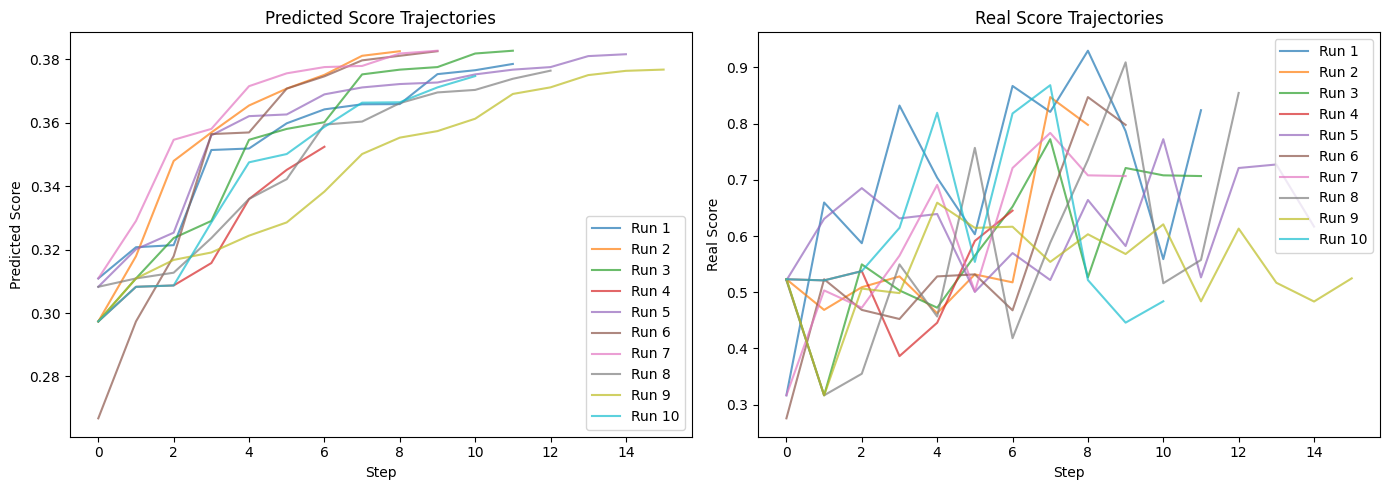

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted scores
for run_id in df_all_walks['run_id'].unique():
    run_data = df_all_walks[df_all_walks['run_id'] == run_id]
    axes[0].plot(run_data['step'], run_data['predicted_score'], alpha=0.7, label=f'Run {run_id}')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Predicted Score')
axes[0].set_title('Predicted Score Trajectories')
axes[0].legend()

# Real scores
for run_id in df_all_walks['run_id'].unique():
    run_data = df_all_walks[df_all_walks['run_id'] == run_id]
    axes[1].plot(run_data['step'], run_data['real_score'], alpha=0.7, label=f'Run {run_id}')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Real Score')
axes[1].set_title('Real Score Trajectories')
axes[1].legend()

plt.tight_layout()
plt.show()

/Users/meier/Documents/PracticalWork/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/meier/Documents/PracticalWork/.venv/lib/python3.9/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


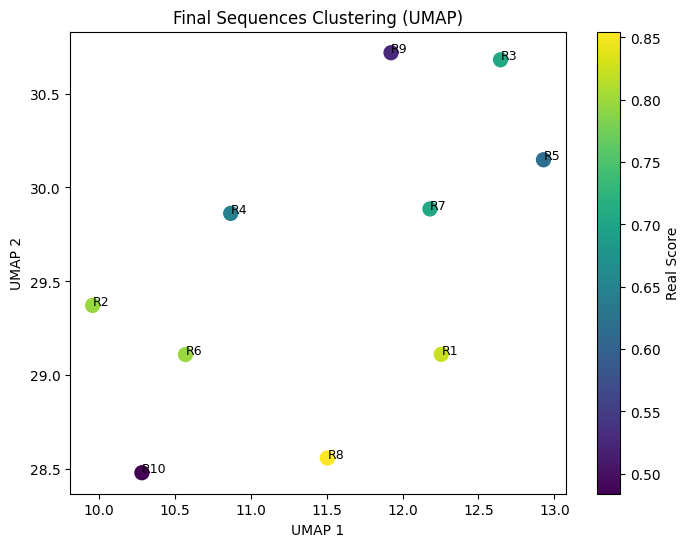

In [14]:
import umap
# Get final sequence from each run
final_seqs = df_all_walks.groupby('run_id').last()
X_final = np.vstack(final_seqs['mutation'].values)
scores_final = final_seqs['real_score'].values

reducer = umap.UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(X_final)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=scores_final, cmap='viridis', s=100)
for i, run_id in enumerate(final_seqs.index):
    plt.annotate(f'R{run_id}', (embedding[i, 0], embedding[i, 1]), fontsize=9)
plt.colorbar(scatter, label='Real Score')
plt.title('Final Sequences Clustering (UMAP)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

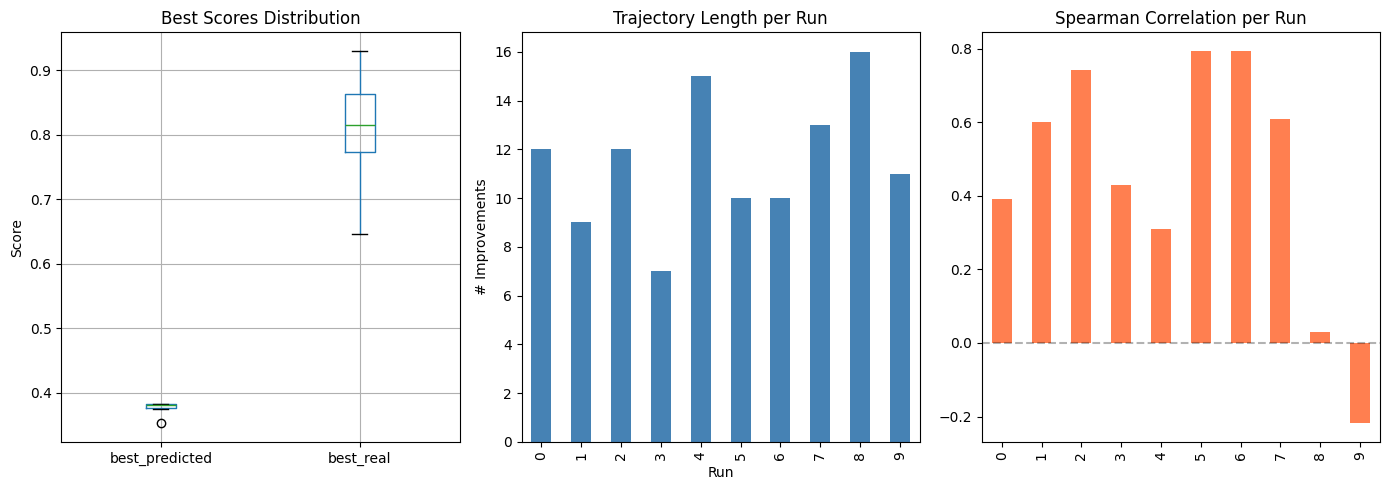

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Best scores comparison
per_run_stats[['best_predicted', 'best_real']].boxplot(ax=axes[0])
axes[0].set_title('Best Scores Distribution')
axes[0].set_ylabel('Score')

# Trajectory lengths
per_run_stats['trajectory_length'].plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Trajectory Length per Run')
axes[1].set_xlabel('Run')
axes[1].set_ylabel('# Improvements')

# Spearman correlation
per_run_stats['spearman'].plot(kind='bar', ax=axes[2], color='coral')
axes[2].set_title('Spearman Correlation per Run')
axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

/Users/meier/Documents/PracticalWork/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


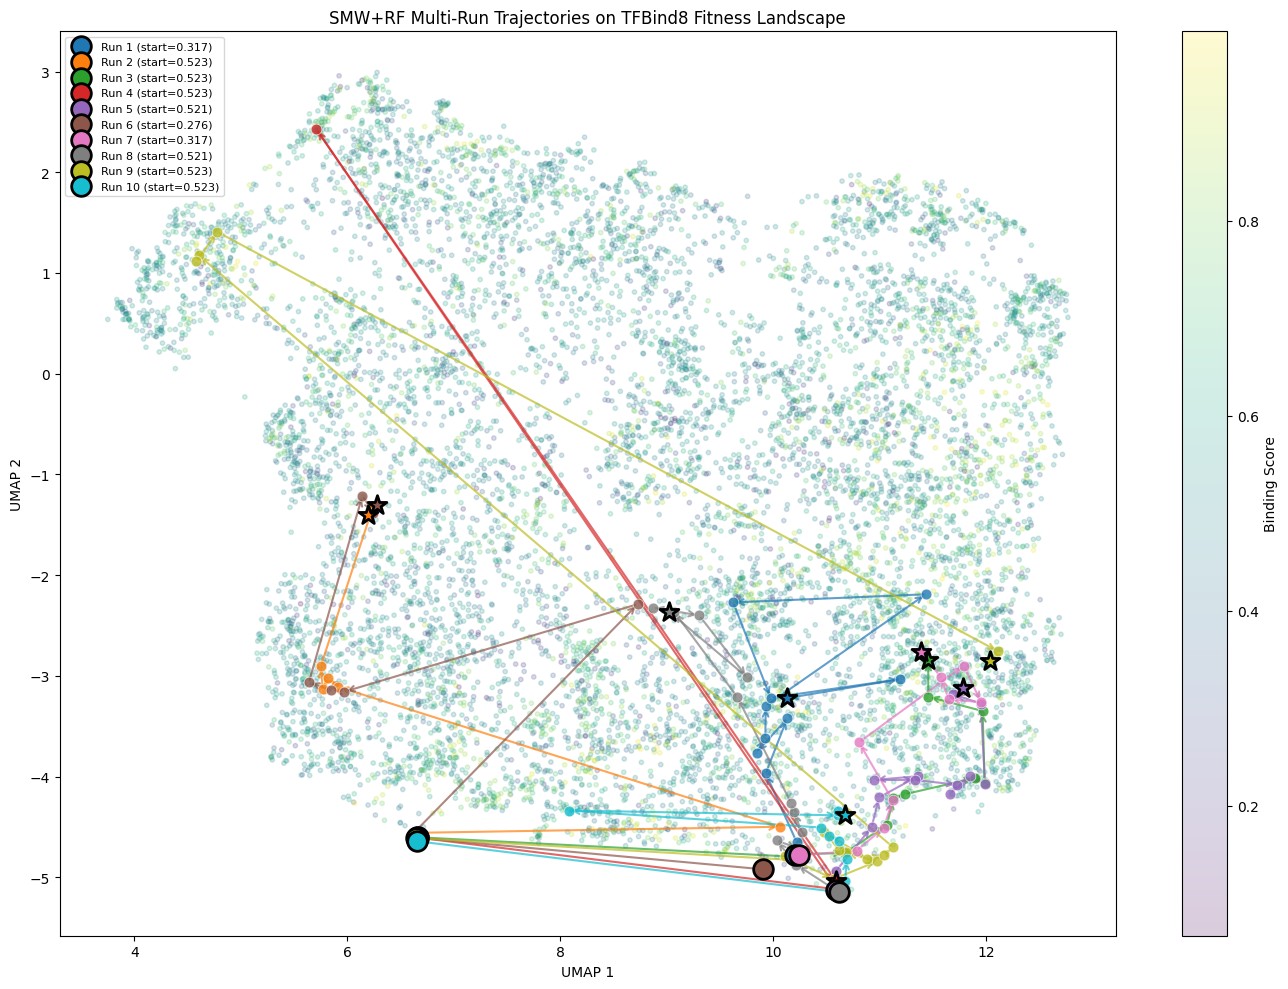

(<Figure size 1400x1000 with 2 Axes>,
 <Axes: title={'center': 'SMW+RF Multi-Run Trajectories on TFBind8 Fitness Landscape'}, xlabel='UMAP 1', ylabel='UMAP 2'>)

In [16]:
from main_scorer import plot_umap_multi_trajectories


import ast
import numpy as np

# Load the CSV
#df_all_walks = pd.read_csv('multiple_walks_all_data.csv')

# Convert string representations back to numpy arrays
def parse_array(s):
    """Convert string representation of array back to numpy array."""
    if isinstance(s, np.ndarray):
        return s
    # Remove brackets and split by whitespace
    s = s.strip('[]')
    values = [float(x) for x in s.split()]
    return np.array(values)

#df_all_walks['mutation'] = df_all_walks['mutation'].apply(parse_array)

# Plot all trajectories on the fitness landscape
plot_umap_multi_trajectories(
    df_oracle=df_oracle,
    df_all_walks=df_all_walks,  # Use the in-memory DataFrame
    SEED=SEED,
    title="SMW+RF Multi-Run Trajectories on TFBind8 Fitness Landscape"
)